In [200]:
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..')) 
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.preprocessing import LabelEncoder

### Загружаем реальные данные

In [201]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
df = pd.read_csv(url, header=None, na_values='?')

# Дадим колонкам имена
df.columns = ['age','workclass','fnlwgt','education','education-num',
              'marital-status','occupation','relationship','race','sex',
              'capital-gain','capital-loss','hours-per-week','native-country','income']

# Удалим строки с пропусками (CTGAN не любит NaN)
df = df.dropna().reset_index(drop=True)

# Категориальные – по именам (соответствуют твоим индексам 0,3,4,5,6,8,9,11,12,15) [web:20]
discrete_columns = ['workclass','education','marital-status','occupation',
                    'relationship','race','sex','native-country','income']

### Выведем небольшую часть датсетов и их размерности

#### Реальные данные 

In [202]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [203]:
df.shape

(32561, 15)

#### Данные от KAN-CTGAN-DP

In [204]:
base_dir = os.path.abspath('../..')
file_path = os.path.join(base_dir, 'synthetic_output_kan_ctgan_dp.csv')

In [205]:
synthetic_data_kan_ctgan_dp = pd.read_csv(file_path, na_values='?')

In [206]:
synthetic_data_kan_ctgan_dp.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,45,Self-emp-not-inc,283509,HS-grad,9,Divorced,Farming-fishing,Unmarried,White,Female,16,-3,60,United-States,<=50K
1,16,?,666929,7th-8th,14,Never-married,?,Other-relative,White,Male,-67,-3,22,Dominican-Republic,<=50K
2,16,Private,120970,HS-grad,9,Never-married,?,Own-child,White,Male,20,-2,40,United-States,<=50K
3,15,Private,126998,HS-grad,9,Never-married,Craft-repair,Own-child,White,Male,28,-1,40,United-States,<=50K
4,63,Self-emp-not-inc,140598,Masters,14,Divorced,Prof-specialty,Unmarried,White,Male,25,2,40,United-States,<=50K


In [207]:
synthetic_data_kan_ctgan_dp.shape

(32561, 15)

#### Данные от CTGAN

In [208]:
base_dir = os.path.abspath('../..')
file_path = os.path.join(base_dir, 'synthetic_output_ctgan.csv')

In [209]:
synthetic_data_ctgan = pd.read_csv(file_path, na_values='?')

In [210]:
synthetic_data_ctgan.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,32,Private,242768,Assoc-voc,9,Never-married,Farming-fishing,Not-in-family,White,Female,3,0,35,Ireland,<=50K
1,56,?,189009,Bachelors,13,Married-AF-spouse,?,Wife,White,Female,7,1,18,United-States,<=50K
2,53,Federal-gov,40936,Some-college,10,Divorced,Adm-clerical,Unmarried,White,Female,-7,1,22,United-States,<=50K
3,45,Private,284977,Masters,7,Married-spouse-absent,Craft-repair,Not-in-family,White,Male,-14,1,40,Cuba,<=50K
4,30,Private,260380,9th,6,Never-married,Armed-Forces,Not-in-family,White,Male,13,1,40,United-States,<=50K


In [211]:
synthetic_data_ctgan.shape

(32561, 15)

### Выведем распределения данных

### Train/Test split для df

In [212]:
col = 'age'

In [213]:
X_df = df.drop(col, axis=1)
y_df = df[col]

In [214]:
X_df_train, X_df_test, y_df_train, y_df_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

### Train/Test split для synthetic_data_kan_ctgan_dp

In [215]:
X_synt_kan_ctgan = synthetic_data_kan_ctgan_dp.drop(col, axis=1)
y_synt_kan_ctgan = synthetic_data_kan_ctgan_dp[col]

In [216]:
X_synt_kan_ctgan_train, X_synt_kan_ctgan_test, y_synt_kan_ctgan_train, y_synt_kan_ctgan_test = train_test_split(X_synt_kan_ctgan, y_synt_kan_ctgan, test_size=0.2, random_state=42)

### Train/Test split для synthetic_data_ctgan

In [217]:
X_synt_ctgan = synthetic_data_ctgan.drop(col, axis=1)
y_synt_ctgan = synthetic_data_ctgan[col]

In [218]:
X_synt_ctgan_train, X_synt_ctgan_test, y_synt_ctgan_train, y_synt_ctgan_test = train_test_split(X_synt_ctgan, y_synt_ctgan, test_size=0.2, random_state=42)

### Обучаем модель: На реальных данных, синтетике от кастомной модели и синтетике от CTGAN

In [219]:
def encode_X(X):
    le = LabelEncoder()
    X_enc = X.copy()
    for col in X_enc.select_dtypes(include='object').columns:
        X_enc[col] = le.fit_transform(X_enc[col].astype(str))
    return X_enc

In [220]:
X_train_enc_1 = encode_X(X_df_train)
X_test_enc_1 = encode_X(X_df_test)

In [221]:
model = RandomForestRegressor(n_estimators=100, random_state=42)

In [222]:
model.fit(X_train_enc_1, y_df_train)
df_preds = model.predict(X_test_enc_1)
df_preds

array([49.34, 45.14, 45.25, ..., 49.2 , 29.88, 24.79])

In [223]:
X_train_enc_2 = encode_X(X_synt_kan_ctgan_train)
X_test_enc_2 = encode_X(X_synt_kan_ctgan_test)

In [224]:
model.fit(X_train_enc_2, y_synt_kan_ctgan_train)
kan_ctgan_dp_preds = model.predict(X_test_enc_1)
kan_ctgan_dp_preds

array([43.22, 41.58, 43.59, ..., 48.17, 39.3 , 32.36])

In [225]:
X_train_enc_3 = encode_X(X_synt_ctgan_train)
X_test_enc_3 = encode_X(X_synt_ctgan_test)

In [226]:
model.fit(X_train_enc_3, y_synt_ctgan_train)
ctgan_preds = model.predict(X_test_enc_1)
ctgan_preds

array([44.52, 44.35, 45.94, ..., 53.  , 32.07, 37.02])

### Сравним метрики

In [227]:
mae_real = mean_absolute_error(y_df_test, df_preds)
r2_real = r2_score(y_df_test, df_preds)

print("MAE:", mean_absolute_error(y_df_test, df_preds))
print("RMSE:", mean_squared_error(y_df_test, df_preds))
print("R2:", r2_score(y_df_test, df_preds))

MAE: 8.173312455674731
RMSE: 110.31936028051824
R2: 0.4062186724673632


In [228]:
mae_kan = mean_absolute_error(y_df_test, kan_ctgan_dp_preds)
r2_kan = r2_score(y_df_test, kan_ctgan_dp_preds)

print("MAE:", mean_absolute_error(y_df_test, kan_ctgan_dp_preds))
print("RMSE:", mean_squared_error(y_df_test, kan_ctgan_dp_preds))
print("R2:", r2_score(y_df_test, kan_ctgan_dp_preds))

MAE: 10.554748963611237
RMSE: 185.94504065714727
R2: -0.0008278946574793444


In [229]:
mae_ctgan = mean_absolute_error(y_df_test, ctgan_preds)
r2_ctgan = r2_score(y_df_test, ctgan_preds)

print("MAE:", mean_absolute_error(y_df_test, ctgan_preds))
print("RMSE:", mean_squared_error(y_df_test, ctgan_preds))
print("R2:", r2_score(y_df_test, ctgan_preds))

MAE: 9.14901427913404
RMSE: 127.41305458314142
R2: 0.31421381974124507


In [230]:
# Utility Score — насколько близко к реальному
utility_kan = 1 - (mae_kan - mae_real) / mae_real
utility_ctgan = 1 - (mae_ctgan - mae_real) / mae_real

print(f"Utility KAN-CTGAN-DP: {utility_kan:.3f}")
print(f"Utility CTGAN:        {utility_ctgan:.3f}")

# Относительная потеря R2
r2_loss_kan = (r2_real - r2_kan) / abs(r2_real) * 100
r2_loss_ctgan = (r2_real - r2_ctgan) / abs(r2_real) * 100

print(f"\nПотеря R2 KAN-CTGAN-DP: {r2_loss_kan:.1f}%")
print(f"Потеря R2 CTGAN:        {r2_loss_ctgan:.1f}%")

Utility KAN-CTGAN-DP: 0.709
Utility CTGAN:        0.881

Потеря R2 KAN-CTGAN-DP: 100.2%
Потеря R2 CTGAN:        22.6%


### Рассмотрим распределение данных

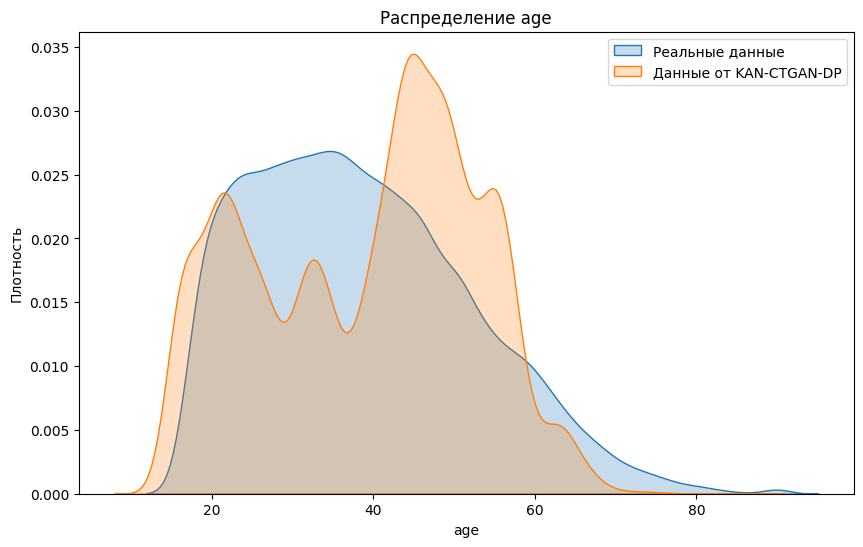

In [231]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[col], label = 'Реальные данные', fill=True)
sns.kdeplot(synthetic_data_kan_ctgan_dp[col], label = 'Данные от KAN-CTGAN-DP', fill=True)
plt.title(f'Распределение {col}')
plt.xlabel(col)
plt.ylabel('Плотность')
plt.legend()
plt.show()

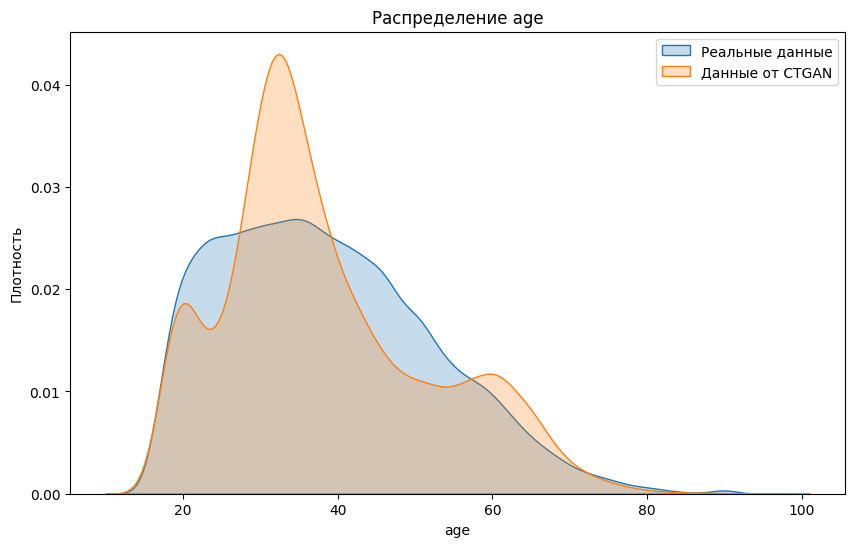

In [232]:
plt.figure(figsize=(10,6))
sns.kdeplot(df[col], label = 'Реальные данные', fill=True)
sns.kdeplot(synthetic_data_ctgan[col], label = 'Данные от CTGAN', fill=True)
plt.title(f'Распределение {col}')
plt.xlabel(col)
plt.ylabel('Плотность')
plt.legend()
plt.show()